In [3]:
# Load the pandas package and create the dataset 
import pandas as pd 
data = { 
'Country' : ['South Korea', 'China', 'Canada', 'South Korea', 'China', 'Canada', 'South Korea', 'China', 'Canada'],
'Medal' : ['gold', 'gold', 'gold', 'silver', 'silver', 'silver', 'bronze', 'bronze', 'bronze'], 
'Count' : [24, 10, 9, 13, 15, 12, 11, 8, 12] 
} 
df = pd.DataFrame(data) 
df

,Country,Medal,Count
0,South Korea,gold,24
1,China,gold,10
2,Canada,gold,9
3,South Korea,silver,13
4,China,silver,15
5,Canada,silver,12
6,South Korea,bronze,11
7,China,bronze,8
8,Canada,bronze,12


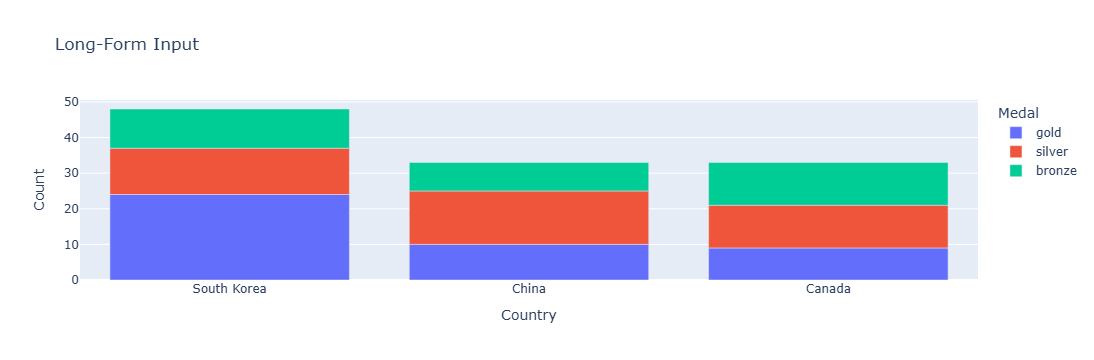

In [5]:
import plotly.express as px   
#long_df = px.data.medals_long() 
fig = px.bar(df, x="Country", y="Count", color="Medal", title="Long-Form Input") 
fig.show() 

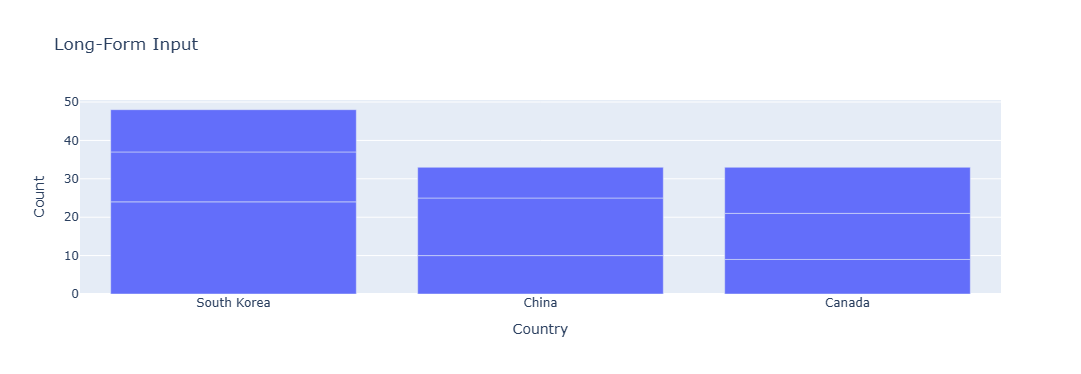

In [10]:
import plotly.express as px   
#long_df = px.data.medals_long() 
fig = px.bar(df, x="Country", y="Count", color="Medal", title="Long-Form Input") 
fig.show() 

In [15]:
pip install dash

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 228.8 kB/s eta 0:00:35
   -- ------------------------------------- 0.5/8.4 MB 228.8 kB/s eta 0:00:35
   -- ------------------------------------- 0.5/8.4 MB 228.8 kB/s eta 0:00:35
   -- ------------------------------------- 0.5/8.4 MB 228.8 kB/s eta 0:00:3

In [18]:

from dash import Dash, dcc, html, Input, Output
import plotly.express as px 
app = Dash(__name__) 
app.layout = html.Div([ 
    html.H1('Restaurant tips by day of week'), 
    dcc.Dropdown( 
        id="dropdown", 
        options=['Mon', "Fri", "Sat", "Sun"], 
        value="Fri", 
        clearable=False, 
    ), 
    dcc.Graph(id="graph"), ]) 
@app.callback( 
    Output("graph", "figure"), 
    Input("dropdown", "value")) 
def update_bar_chart(day): 
    df = px.data.tips() # replace with your own data source 
    mask = df["day"] == day 
    fig = px.bar(df[mask], x="sex", y="total_bill", color="smoker", barmode="group") 
    return fig 
app.run(debug=True)

In [19]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# ================================
# LOAD DATA
# ================================
df = pd.read_excel(r'C:\Users\ISUG\Documents\Qiyas\COVID-19-geographic-disbtribution-worldwide.xlsx')

# Extract African data only
africa_df = df[df['continentExp'] == 'Africa']

# Get unique months for dropdown
months = sorted(africa_df['month'].unique().tolist())

# ================================
# CREATE APP
# ================================
app = Dash(__name__)

app.layout = html.Div([

    html.H1('COVID-19 Africa Dashboard'),

    # Dropdown 1 - Month
    html.Label('Select Month:'),
    dcc.Dropdown(
        id='month-dropdown',
        options=[{'label': f'Month {m}', 'value': m} for m in months],
        value=months[0],
        clearable=False,
    ),

    # Graph 1 - Cases per country
    dcc.Graph(id='cases-graph'),

    # Graph 2 - Deaths per country
    dcc.Graph(id='deaths-graph'),

    # Graph 3 - Cases vs Deaths scatter
    dcc.Graph(id='scatter-graph'),

])

# ================================
# CALLBACK - Update all 3 charts
# ================================
@app.callback(
    Output('cases-graph', 'figure'),
    Output('deaths-graph', 'figure'),
    Output('scatter-graph', 'figure'),
    Input('month-dropdown', 'value')
)
def update_charts(selected_month):

    # Filter by selected month
    filtered = africa_df[africa_df['month'] == selected_month]

    # Group by country
    country_stats = filtered.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().reset_index()

    # Chart 1 - Bar chart: Cases per country
    fig1 = px.bar(
        country_stats,
        x='countriesAndTerritories',
        y='cases',
        color='countriesAndTerritories',
        title=f'Total Cases per African Country - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'cases': 'Total Cases'}
    )

    # Chart 2 - Bar chart: Deaths per country
    fig2 = px.bar(
        country_stats,
        x='countriesAndTerritories',
        y='deaths',
        color='countriesAndTerritories',
        title=f'Total Deaths per African Country - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'deaths': 'Total Deaths'}
    )

    # Chart 3 - Scatter: Cases vs Deaths
    fig3 = px.scatter(
        country_stats,
        x='cases',
        y='deaths',
        color='countriesAndTerritories',
        size='cases',
        title=f'Cases vs Deaths - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country'}
    )

    return fig1, fig2, fig3

if __name__ == '__main__':
    app.run(debug=True)

In [20]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# ================================
# LOAD DATA
# ================================
df = pd.read_excel(r'C:\Users\ISUG\Documents\Qiyas\COVID-19-geographic-disbtribution-worldwide.xlsx')

# Extract African data only
africa_df = df[df['continentExp'] == 'Africa'].copy()

# Fix date column
africa_df['dateRep'] = pd.to_datetime(africa_df[['year', 'month', 'day']])

# Get unique values for dropdowns
months    = sorted(africa_df['month'].unique().tolist())
countries = sorted(africa_df['countriesAndTerritories'].unique().tolist())

# ================================
# CREATE APP
# ================================
app = Dash(__name__)

app.layout = html.Div([

    html.H1('🌍 COVID-19 Africa Interactive Dashboard',
            style={'textAlign': 'center', 'color': 'darkred'}),

    # ── DROPDOWNS ROW ──
    html.Div([

        # Month Dropdown
        html.Div([
            html.Label('📅 Select Month:'),
            dcc.Dropdown(
                id='month-dropdown',
                options=[{'label': f'Month {m}', 'value': m} for m in months],
                value=months[0],
                clearable=False,
            ),
        ], style={'width': '45%', 'display': 'inline-block', 'marginRight': '5%'}),

        # Country Dropdown
        html.Div([
            html.Label('🌍 Select Country:'),
            dcc.Dropdown(
                id='country-dropdown',
                options=[{'label': c, 'value': c} for c in countries],
                value='Ethiopia',
                clearable=False,
            ),
        ], style={'width': '45%', 'display': 'inline-block'}),

    ], style={'padding': '20px'}),

    html.Hr(),

    # ── ROW 1 - Bar charts ──
    html.Div([
        html.Div([dcc.Graph(id='cases-graph')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='deaths-graph')],
                 style={'width': '48%', 'display': 'inline-block', 'marginLeft': '4%'}),
    ]),

    # ── ROW 2 - Scatter + Line ──
    html.Div([
        html.Div([dcc.Graph(id='scatter-graph')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='line-graph')],
                 style={'width': '48%', 'display': 'inline-block', 'marginLeft': '4%'}),
    ]),

    # ── ROW 3 - Death Rate ──
    html.Div([dcc.Graph(id='deathrate-graph')]),

])

# ================================
# CALLBACK
# ================================
@app.callback(
    Output('cases-graph',     'figure'),
    Output('deaths-graph',    'figure'),
    Output('scatter-graph',   'figure'),
    Output('line-graph',      'figure'),
    Output('deathrate-graph', 'figure'),
    Input('month-dropdown',   'value'),
    Input('country-dropdown', 'value')
)
def update_charts(selected_month, selected_country):

    # ── Filter by month ──
    monthly = africa_df[africa_df['month'] == selected_month]
    country_stats = monthly.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().reset_index()

    # ── Filter by country ──
    country_data = africa_df[africa_df['countriesAndTerritories'] == selected_country].copy()
    country_data = country_data.sort_values('dateRep')

    # ── Death rate ──
    country_stats['death_rate'] = (country_stats['deaths'] / country_stats['cases'].replace(0, 1)) * 100

    # ── Chart 1 - Cases per country (selected month) ──
    fig1 = px.bar(
        country_stats.sort_values('cases', ascending=False),
        x='countriesAndTerritories',
        y='cases',
        color='countriesAndTerritories',
        title=f'Total Cases per Country - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'cases': 'Cases'}
    )

    # ── Chart 2 - Deaths per country (selected month) ──
    fig2 = px.bar(
        country_stats.sort_values('deaths', ascending=False),
        x='countriesAndTerritories',
        y='deaths',
        color='countriesAndTerritories',
        title=f'Total Deaths per Country - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'deaths': 'Deaths'}
    )

    # ── Chart 3 - Cases vs Deaths scatter ──
    fig3 = px.scatter(
        country_stats,
        x='cases',
        y='deaths',
        color='countriesAndTerritories',
        size='cases',
        title=f'Cases vs Deaths Scatter - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country'}
    )

    # ── Chart 4 - Daily line chart for selected country ──
    fig4 = px.line(
        country_data,
        x='dateRep',
        y=['cases', 'deaths'],
        title=f'Daily Cases and Deaths - {selected_country}',
        labels={'dateRep': 'Date', 'value': 'Count'}
    )

    # ── Chart 5 - Death rate bar chart ──
    fig5 = px.bar(
        country_stats.sort_values('death_rate', ascending=False),
        x='countriesAndTerritories',
        y='death_rate',
        color='death_rate',
        color_continuous_scale='Reds',
        title=f'Death Rate per Country (%) - Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'death_rate': 'Death Rate (%)'}
    )

    return fig1, fig2, fig3, fig4, fig5

if __name__ == '__main__':
    app.run(debug=True)

In [21]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# ================================
# LOAD DATA
# ================================
df = pd.read_excel(r'C:\Users\ISUG\Documents\Qiyas\COVID-19-geographic-disbtribution-worldwide.xlsx')

# Extract African data only
africa_df = df[df['continentExp'] == 'Africa'].copy()

# Fix date column
africa_df['dateRep'] = pd.to_datetime(africa_df[['year', 'month', 'day']])

# Get unique values for dropdowns
years     = sorted(africa_df['year'].unique().tolist())
months    = sorted(africa_df['month'].unique().tolist())
dates     = sorted(africa_df['dateRep'].dt.strftime('%Y-%m-%d').unique().tolist())
countries = sorted(africa_df['countriesAndTerritories'].unique().tolist())

# ================================
# CREATE APP
# ================================
app = Dash(__name__)

app.layout = html.Div([

    html.H1('🌍 COVID-19 Africa Interactive Dashboard',
            style={'textAlign': 'center', 'color': 'darkred'}),

    # ================================
    # DROPDOWNS ROW
    # ================================
    html.Div([

        # Year Dropdown
        html.Div([
            html.Label('📅 Select Year:'),
            dcc.Dropdown(
                id='year-dropdown',
                options=[{'label': str(y), 'value': y} for y in years],
                value=years[0],
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Month Dropdown
        html.Div([
            html.Label('📅 Select Month:'),
            dcc.Dropdown(
                id='month-dropdown',
                options=[{'label': f'Month {m}', 'value': m} for m in months],
                value=months[0],
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Date Dropdown
        html.Div([
            html.Label('📅 Select Date:'),
            dcc.Dropdown(
                id='date-dropdown',
                options=[{'label': d, 'value': d} for d in dates],
                value=dates[0],
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Country Dropdown
        html.Div([
            html.Label('🌍 Select Country:'),
            dcc.Dropdown(
                id='country-dropdown',
                options=[{'label': c, 'value': c} for c in countries],
                value='Ethiopia',
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block'}),

    ], style={'padding': '20px'}),

    html.Hr(),

    # ================================
    # ROW 1 - Cases and Deaths by Month
    # ================================
    html.Div([
        html.Div([dcc.Graph(id='cases-by-month')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='deaths-by-month')],
                 style={'width': '48%', 'display': 'inline-block',
                        'marginLeft': '4%'}),
    ]),

    # ================================
    # ROW 2 - Cases and Deaths by Date
    # ================================
    html.Div([
        html.Div([dcc.Graph(id='cases-by-date')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='deaths-by-date')],
                 style={'width': '48%', 'display': 'inline-block',
                        'marginLeft': '4%'}),
    ]),

    # ================================
    # ROW 3 - Country Daily Trend + Death Rate
    # ================================
    html.Div([
        html.Div([dcc.Graph(id='country-trend')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='death-rate')],
                 style={'width': '48%', 'display': 'inline-block',
                        'marginLeft': '4%'}),
    ]),

])

# ================================
# CALLBACK
# ================================
@app.callback(
    Output('cases-by-month',  'figure'),
    Output('deaths-by-month', 'figure'),
    Output('cases-by-date',   'figure'),
    Output('deaths-by-date',  'figure'),
    Output('country-trend',   'figure'),
    Output('death-rate',      'figure'),
    Input('year-dropdown',    'value'),
    Input('month-dropdown',   'value'),
    Input('date-dropdown',    'value'),
    Input('country-dropdown', 'value')
)
def update_charts(selected_year, selected_month, selected_date, selected_country):

    # ── Filter by year ──
    yearly = africa_df[africa_df['year'] == selected_year]

    # ── Filter by month ──
    monthly = yearly[yearly['month'] == selected_month]
    monthly_stats = monthly.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().reset_index()

    # ── Filter by date ──
    daily = africa_df[africa_df['dateRep'].dt.strftime('%Y-%m-%d') == selected_date]
    daily_stats = daily.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().reset_index()

    # ── Filter by country ──
    country_data = africa_df[
        africa_df['countriesAndTerritories'] == selected_country
    ].sort_values('dateRep')

    # ── Death rate ──
    monthly_stats['death_rate'] = (
        monthly_stats['deaths'] / monthly_stats['cases'].replace(0, 1)
    ) * 100

    # ── Chart 1 - Cases per country by month ──
    fig1 = px.bar(
        monthly_stats.sort_values('cases', ascending=False),
        x='countriesAndTerritories',
        y='cases',
        color='countriesAndTerritories',
        title=f'Cases per Country - Year {selected_year} Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'cases': 'Cases'}
    )

    # ── Chart 2 - Deaths per country by month ──
    fig2 = px.bar(
        monthly_stats.sort_values('deaths', ascending=False),
        x='countriesAndTerritories',
        y='deaths',
        color='countriesAndTerritories',
        title=f'Deaths per Country - Year {selected_year} Month {selected_month}',
        labels={'countriesAndTerritories': 'Country', 'deaths': 'Deaths'}
    )

    # ── Chart 3 - Cases per country by date ──
    fig3 = px.bar(
        daily_stats.sort_values('cases', ascending=False),
        x='countriesAndTerritories',
        y='cases',
        color='countriesAndTerritories',
        title=f'Cases per Country - {selected_date}',
        labels={'countriesAndTerritories': 'Country', 'cases': 'Cases'}
    )

    # ── Chart 4 - Deaths per country by date ──
    fig4 = px.bar(
        daily_stats.sort_values('deaths', ascending=False),
        x='countriesAndTerritories',
        y='deaths',
        color='countriesAndTerritories',
        title=f'Deaths per Country - {selected_date}',
        labels={'countriesAndTerritories': 'Country', 'deaths': 'Deaths'}
    )

    # ── Chart 5 - Daily trend for selected country ──
    fig5 = px.line(
        country_data,
        x='dateRep',
        y=['cases', 'deaths'],
        title=f'Daily Cases and Deaths - {selected_country}',
        labels={'dateRep': 'Date', 'value': 'Count'}
    )

    # ── Chart 6 - Death rate per country ──
    fig6 = px.bar(
        monthly_stats.sort_values('death_rate', ascending=False),
        x='countriesAndTerritories',
        y='death_rate',
        color='death_rate',
        color_continuous_scale='Reds',
        title=f'Death Rate (%) - Year {selected_year} Month {selected_month}',
        labels={'countriesAndTerritories': 'Country',
                'death_rate': 'Death Rate (%)'}
    )

    return fig1, fig2, fig3, fig4, fig5, fig6

if __name__ == '__main__':
    app.run(debug=True)

In [22]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# ================================
# LOAD DATA
# ================================
df = pd.read_excel(r'C:\Users\ISUG\Documents\Qiyas\COVID-19-geographic-disbtribution-worldwide.xlsx')

# Extract African data only
africa_df = df[df['continentExp'] == 'Africa'].copy()

# Fix date column
africa_df['dateRep'] = pd.to_datetime(africa_df[['year', 'month', 'day']])

# Get unique values for dropdowns
years     = sorted(africa_df['year'].unique().tolist())
months    = sorted(africa_df['month'].unique().tolist())
dates     = sorted(africa_df['dateRep'].dt.strftime('%Y-%m-%d').unique().tolist())
countries = sorted(africa_df['countriesAndTerritories'].unique().tolist())

# ================================
# CREATE APP
# ================================
app = Dash(__name__)

app.layout = html.Div([

    html.H1('🌍 COVID-19 Africa Interactive Dashboard',
            style={'textAlign': 'center', 'color': 'darkred'}),

    # ================================
    # DROPDOWNS ROW
    # ================================
    html.Div([

        # Year Dropdown
        html.Div([
            html.Label('📅 Select Year:'),
            dcc.Dropdown(
                id='year-dropdown',
                options=[{'label': str(y), 'value': y} for y in years],
                value=years[0],
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Month Dropdown
        html.Div([
            html.Label('📅 Select Month:'),
            dcc.Dropdown(
                id='month-dropdown',
                options=[{'label': f'Month {m}', 'value': m} for m in months],
                value=months[0],
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Date Dropdown
        html.Div([
            html.Label('📅 Select Date:'),
            dcc.Dropdown(
                id='date-dropdown',
                options=[{'label': d, 'value': d} for d in dates],
                value=dates[0],
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Country Dropdown
        html.Div([
            html.Label('🌍 Select Country:'),
            dcc.Dropdown(
                id='country-dropdown',
                options=[{'label': c, 'value': c} for c in countries],
                value='Ethiopia',
                clearable=False,
            ),
        ], style={'width': '22%', 'display': 'inline-block'}),

    ], style={'padding': '20px'}),

    html.Hr(),

    # ================================
    # ROW 1 - Cases by Date + Deaths by Date
    # ================================
    html.Div([
        html.Div([dcc.Graph(id='cases-by-date')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='deaths-by-date')],
                 style={'width': '48%', 'display': 'inline-block',
                        'marginLeft': '4%'}),
    ]),

    # ================================
    # ROW 2 - Country Daily Trend + Death Rate
    # ================================
    html.Div([
        html.Div([dcc.Graph(id='country-trend')],
                 style={'width': '48%', 'display': 'inline-block'}),
        html.Div([dcc.Graph(id='death-rate')],
                 style={'width': '48%', 'display': 'inline-block',
                        'marginLeft': '4%'}),
    ]),

])

# ================================
# CALLBACK
# ================================
@app.callback(
    Output('cases-by-date',   'figure'),
    Output('deaths-by-date',  'figure'),
    Output('country-trend',   'figure'),
    Output('death-rate',      'figure'),
    Input('year-dropdown',    'value'),
    Input('month-dropdown',   'value'),
    Input('date-dropdown',    'value'),
    Input('country-dropdown', 'value')
)
def update_charts(selected_year, selected_month, selected_date, selected_country):

    # Filter by year and month
    yearly  = africa_df[africa_df['year'] == selected_year]
    monthly = yearly[yearly['month'] == selected_month]
    monthly_stats = monthly.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().reset_index()

    # Filter by date
    daily = africa_df[africa_df['dateRep'].dt.strftime('%Y-%m-%d') == selected_date]
    daily_stats = daily.groupby('countriesAndTerritories')[['cases', 'deaths']].sum().reset_index()

    # Filter by country
    country_data = africa_df[
        africa_df['countriesAndTerritories'] == selected_country
    ].sort_values('dateRep')

    # Death rate
    monthly_stats['death_rate'] = (
        monthly_stats['deaths'] / monthly_stats['cases'].replace(0, 1)
    ) * 100

    # Chart 1 - Cases per country by date
    fig1 = px.bar(
        daily_stats.sort_values('cases', ascending=False),
        x='countriesAndTerritories',
        y='cases',
        color='countriesAndTerritories',
        title=f'Cases per Country - {selected_date}',
        labels={'countriesAndTerritories': 'Country', 'cases': 'Cases'}
    )

    # Chart 2 - Deaths per country by date
    fig2 = px.bar(
        daily_stats.sort_values('deaths', ascending=False),
        x='countriesAndTerritories',
        y='deaths',
        color='countriesAndTerritories',
        title=f'Deaths per Country - {selected_date}',
        labels={'countriesAndTerritories': 'Country', 'deaths': 'Deaths'}
    )

    # Chart 3 - Daily trend for selected country
    fig3 = px.line(
        country_data,
        x='dateRep',
        y=['cases', 'deaths'],
        title=f'Daily Cases and Deaths - {selected_country}',
        labels={'dateRep': 'Date', 'value': 'Count'}
    )

    # Chart 4 - Death rate per country
    fig4 = px.bar(
        monthly_stats.sort_values('death_rate', ascending=False),
        x='countriesAndTerritories',
        y='death_rate',
        color='death_rate',
        color_continuous_scale='Reds',
        title=f'Death Rate (%) - Year {selected_year} Month {selected_month}',
        labels={'countriesAndTerritories': 'Country',
                'death_rate': 'Death Rate (%)'}
    )

    return fig1, fig2, fig3, fig4

if __name__ == '__main__':
    app.run(debug=True)

In [23]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# ================================
# LOAD DATA
# ================================
df = pd.read_excel(r'C:\Users\ISUG\Documents\Qiyas\COVID-19-geographic-disbtribution-worldwide.xlsx')

# Fix date column
df['dateRep'] = pd.to_datetime(df[['year', 'month', 'day']])

# Get unique values for dropdowns
continents = sorted(df['continentExp'].unique().tolist())
dates      = sorted(df['dateRep'].dt.strftime('%Y-%m-%d').unique().tolist())

# ================================
# CREATE APP
# ================================
app = Dash(__name__)

app.layout = html.Div([

    html.H1('🌍 COVID-19 Interactive Dashboard',
            style={'textAlign': 'center', 'color': 'darkred'}),

    # ================================
    # DROPDOWNS ROW
    # ================================
    html.Div([

        # Date Dropdown
        html.Div([
            html.Label('📅 Select Date:'),
            dcc.Dropdown(
                id='date-dropdown',
                options=[{'label': d, 'value': d} for d in dates],
                value=dates[0],
                clearable=False,
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Continent Dropdown
        html.Div([
            html.Label('🌍 Select Continent:'),
            dcc.Dropdown(
                id='continent-dropdown',
                options=[{'label': c, 'value': c} for c in continents],
                value='Africa',
                clearable=False,
            ),
        ], style={'width': '30%', 'display': 'inline-block', 'marginRight': '3%'}),

        # Country Dropdown
        html.Div([
            html.Label('🏳️ Select Country:'),
            dcc.Dropdown(
                id='country-dropdown',
                options=[],
                value=None,
                clearable=False,
            ),
        ], style={'width': '30%', 'display': 'inline-block'}),

    ], style={'padding': '20px'}),

    html.Hr(),

    # ================================
    # LINE CHART ONLY
    # ================================
    dcc.Graph(id='line-graph'),

])

# ================================
# CALLBACK 1 - Update country dropdown
# when continent changes
# ================================
@app.callback(
    Output('country-dropdown', 'options'),
    Output('country-dropdown', 'value'),
    Input('continent-dropdown', 'value')
)
def update_country_dropdown(selected_continent):
    # Filter countries by selected continent
    filtered   = df[df['continentExp'] == selected_continent]
    countries  = sorted(filtered['countriesAndTerritories'].unique().tolist())
    options    = [{'label': c, 'value': c} for c in countries]
    default    = 'Ethiopia' if 'Ethiopia' in countries else countries[0]
    return options, default

# ================================
# CALLBACK 2 - Update line chart
# ================================
@app.callback(
    Output('line-graph', 'figure'),
    Input('date-dropdown',      'value'),
    Input('continent-dropdown', 'value'),
    Input('country-dropdown',   'value')
)
def update_chart(selected_date, selected_continent, selected_country):

    if selected_country is None:
        return {}

    # Filter by country
    country_data = df[
        df['countriesAndTerritories'] == selected_country
    ].sort_values('dateRep')

    # Draw line chart
    fig = px.line(
        country_data,
        x='dateRep',
        y=['cases', 'deaths'],
        title=f'Daily Cases and Deaths - {selected_country}',
        labels={'dateRep': 'Date', 'value': 'Count'},
        color_discrete_map={'cases': 'blue', 'deaths': 'red'}
    )

    fig.update_layout(
        legend_title='variable',
        xaxis_title='Date',
        yaxis_title='Count',
        plot_bgcolor='aliceblue'
    )

    return fig

if __name__ == '__main__':
    app.run(debug=True)